## Purpose
In this article we're covering Auto Regression (AR) - one of the foundational models used for time series forecasting. We'll build up an intuition for what makes it different from the regression models we've covered previously, walk through the underlying math, and then implement it from scratch, keeping the code as close to the math as possible. We'll wrap up by fitting our implementation to a real (and famous) dataset: the Wolf sunspot numbers.

## What is Auto Regression
So far in this series we've looked at models that predict a value $y$ from some set of independent features $x_1, x_2, ..., x_n$ (see Linear Regression, Logistic Regression). Auto Regression asks a slightly different question: can we predict the next value in a sequence just from *previous values of that same sequence*?

Think about tomorrow's temperature. A pretty reasonable guess is that it'll look a lot like today's temperature, and today's looked a lot like yesterday's. Or think about a company's quarterly revenue - this quarter is correlated with last quarter, which was correlated with the quarter before that. This is the kind of data we call a **time series**: a sequence of observations ordered in time, where the order matters (unlike the datasets we've used previously, where we could shuffle the rows without losing any information).

Auto Regression (the "auto" meaning "self") models a value in the series as a linear combination of its own previous values, called **lags**, plus some noise. That's really it - it's linear regression, except the "independent features" are just older copies of the target variable itself.

There is a wrinkle though: for this to work well, the series generally needs to be **stationary** - loosely, its mean and variance need to be roughly constant over time. If there's a trend (say, a steadily growing population count) or strong seasonality baked into the series, our AR model can behave poorly unless those effects are removed or modeled first (differencing, detrending, etc.). That's a topic worth its own article, so for our example below we'll pick a series that is naturally close to stationary.

## Math behind Auto Regression
Formally, an Auto Regressive model of order $p$, denoted $AR(p)$, defines the value of our series at time $t$ as:

$$X_t = c + \phi_1 X_{t-1} + \phi_2 X_{t-2} + ... + \phi_p X_{t-p} + \epsilon_t$$

Where:
- $X_t$ is the value of our series at time $t$
- $c$ is a constant (intercept)
- $\phi_1, \phi_2, ..., \phi_p$ are the parameters we're solving for, i.e. how much weight to place on each lag
- $p$ is the **order** of the model - how many time steps back we're looking
- $\epsilon_t$ is white noise, $\epsilon_t \sim (0, \sigma^2)$, uncorrelated with everything else in the equation

Notice this is identical in form to the linear regression equation from a previous post, $\hat{y} = \vec{\beta}\vec{X}$, except our feature vector is built entirely out of lagged copies of the target series, $\vec{X_t} = [1, X_{t-1}, X_{t-2}, ..., X_{t-p}]$, rather than independent features. Because of that, we can reuse the exact same Ordinary Least Squares (OLS) machinery we derived for Linear Regression: stack a row $\vec{X_t}$ for every $t$ from $p+1$ to $T$ into a design matrix $X$, stack the corresponding targets $X_{p+1}, ..., X_T$ into a vector $y$, and our loss function is the same sum of squared residuals as before:

$$L(X,\vec{\phi}) = \sum_{t=p+1}^{T} (\hat{X_t} - X_t)^2 = ||X\vec{\phi} - y||^2$$

which, following the same steps we used for Linear Regression (expand, take the gradient with respect to $\vec\phi$, set it to 0, solve), gives us the closed-form OLS solution:

$$\hat{\vec{\phi}} = (X^TX)^{-1}X^Ty$$

**A quick historical aside.** This model dates back to Udny Yule's 1927 paper explaining sunspot cycles - the very same dataset we'll use below. Yule (and later Gilbert Walker) originally estimated AR parameters using the **Yule-Walker equations**, which work off the autocorrelation function $\rho_k$ of the series instead of solving OLS directly on the design matrix above:

$$\rho_k = \phi_1 \rho_{k-1} + \phi_2 \rho_{k-2} + ... + \phi_p \rho_{k-p}, \qquad k = 1, ..., p$$

(using $\rho_0 = 1$ and $\rho_{-k} = \rho_k$). That's a system of $p$ equations and $p$ unknowns ($\phi_1, ..., \phi_p$) that can be solved directly. Both approaches converge to similar estimates, especially as sample size grows. We'll use plain OLS below since it lets us reuse our regression code almost line for line.

**Forecasting.** Once we have $\hat{\vec\phi}$, predicting one step ahead just means plugging the last $p$ observed values in:

$$\hat X_{T+1} = \hat{c} + \sum_{i=1}^{p} \hat\phi_i X_{T+1-i}$$

To forecast multiple steps ahead, we do it recursively - feeding our own forecasts back in as the "lagged" inputs once we run out of real observations:

$$\hat X_{T+h} = \hat{c} + \sum_{i=1}^{p} \hat\phi_i \hat X_{T+h-i}, \qquad \text{using actual } X \text{ values where } T+h-i \le T$$

One consequence of this recursion: for a stationary $AR(p)$ process, as the forecast horizon $h$ grows, $\hat X_{T+h}$ converges toward the series' unconditional mean:

$$\mu = \frac{c}{1 - \phi_1 - \phi_2 - ... - \phi_p}$$

In other words, the further out you forecast, the less our lagged observations matter, and the more the forecast just reverts to the long run average. We'll see this play out with real numbers in the example below.

## Example
For the example, we'll use the **Wolf sunspot numbers** - yearly counts of sunspots from 1700 to 2008. It's a fitting choice: this is the very dataset Udny Yule used in 1927 when he invented the Auto Regressive model in the first place, trying to explain the roughly 11-year solar cycle. It ships directly with `statsmodels`, so there's nothing to download.

The first thing we need to do is import our libraries. We're pulling in `pandas` and `numpy` as usual, `matplotlib` for visualizing, and `statsmodels` purely to load the dataset and as a diagnostic/cross-check tool later on - the model itself is all NumPy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.datasets import sunspots
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.ar_model import AutoReg

np.random.seed(42)

Here we are reading in the data.

Text(0.5, 0, 'Year')

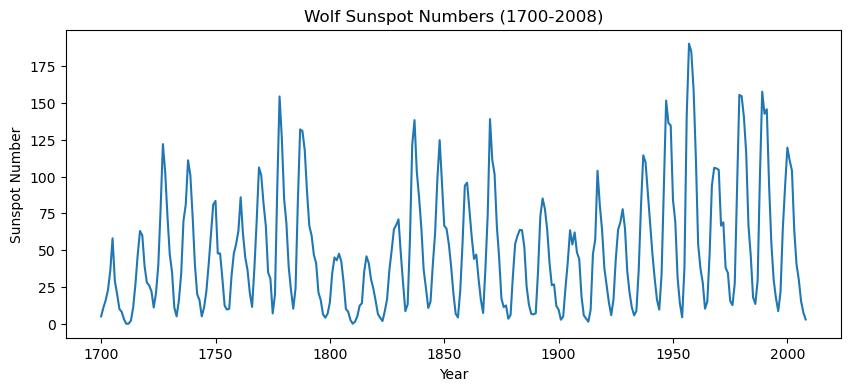

In [2]:
data = sunspots.load_pandas().data
data["YEAR"] = data["YEAR"].astype(int)
series = data.set_index("YEAR")["SUNACTIVITY"]

series.plot(figsize=(10, 4), title="Wolf Sunspot Numbers (1700-2008)")
plt.ylabel("Sunspot Number")
plt.xlabel("Year")

Just from eyeballing the plot, the series oscillates around a roughly constant level - no obvious long-term trend - which is exactly the kind of (close to) stationary behavior AR models like.

Now we build our model object. Just like the `linear_regression` class from a previous post, the `ols()` function fits our model parameters ($\vec\phi$) to the data, and `predict()` applies the fitted model. The only real difference is `make_design_matrix()`, which turns a raw 1-D series into the lagged design matrix $X$ and target vector $y$ from the math section above, row by row.

In [3]:
def make_design_matrix(x, p):
    x = np.asarray(x, dtype=float)
    T = len(x)
    rows = []
    y = []
    for t in range(p, T):
        rows.append([1.0] + [x[t - i] for i in range(1, p + 1)])
        y.append(x[t])
    return np.array(rows), np.array(y)


class AutoRegression:
    def __init__(self, series, p):
        self.p = p
        self.X, self.y = make_design_matrix(series, p)
        self.betas = self.ols(self.X, self.y)

    def ols(self, X, y):
        return np.linalg.pinv(X.T @ X) @ X.T @ y

    def predict(self, series):
        X, _ = make_design_matrix(series, self.p)
        return X @ self.betas

Before fitting, let's split off the last 30 years as a test set, so we have some real out-of-sample data to forecast against later.

In [4]:
test_years = 30
train = series.iloc[:-test_years]
test = series.iloc[-test_years:]
print(f"train: {train.shape[0]} years ({train.index.min()}-{train.index.max()})")
print(f"test:  {test.shape[0]} years ({test.index.min()}-{test.index.max()})")

train: 279 years (1700-1978)
test:  30 years (1979-2008)


There's still one open question: what order $p$ should we use? A common tool for this is the **Partial Autocorrelation Function (PACF)** - the correlation between $X_t$ and $X_{t-k}$ after removing the effect of the lags in between. For a true $AR(p)$ process, the PACF should be roughly zero for lags beyond $p$, giving us a visual cutoff to look for. Let's plot it for our training data.

Text(0.5, 0, 'Lag')

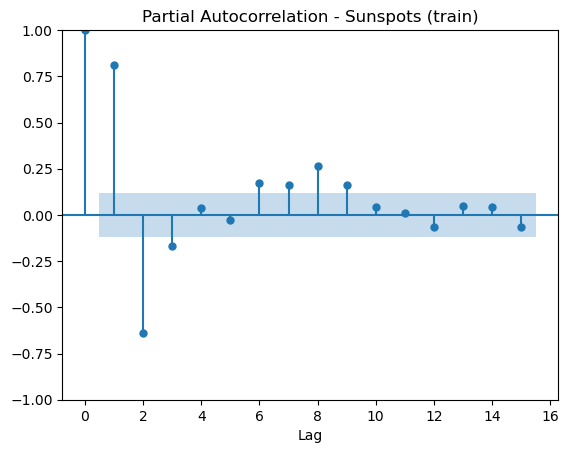

In [5]:
plot_pacf(train, lags=15, title="Partial Autocorrelation - Sunspots (train)")
plt.xlabel("Lag")

There are two clearly significant spikes - at lag 1 and lag 2 - with everything beyond that mostly falling inside the noise band. That points to an $AR(2)$ model, which conveniently is also the order Yule originally used for this exact series. Let's fit it.

In [6]:
p = 2
model = AutoRegression(train.values, p)
print("betas (c, phi_1, phi_2):", model.betas)

betas (c, phi_1, phi_2): [14.64652563  1.37943682 -0.68380781]


To sanity check our from-scratch OLS implementation, let's fit the same order with `statsmodels`' `AutoReg` and compare parameters.

In [7]:
sm_model = AutoReg(train.values, lags=p, old_names=False).fit()
print("our betas:        ", model.betas)
print("statsmodels params:", sm_model.params)

our betas:         [14.64652563  1.37943682 -0.68380781]
statsmodels params: [14.64652563  1.37943682 -0.68380781]


They match exactly - our closed-form OLS solution and `statsmodels`' fitted `AutoReg` model agree to the printed precision.

## Metrics
Since we're predicting a real-valued number, the same metrics from the Linear Regression post apply directly. As a quick recap: with residual $\hat{e_i} = (X_i - \hat{X_i})$,

$$MSE = \frac{1}{n} \sum_{i=1}^n{(\hat{e_i})^2}, \qquad RMSE = \sqrt{MSE}$$

$$R^2 = 1 - \frac{RSS}{TSS}, \qquad RSS = \sum_{i=1}^n{(\hat{e_i})^2}, \qquad TSS = \sum_{i=1}^n{(X_i - \bar{X})^2}$$

The one genuinely new piece for a time series model is **forecasting**: using the model's own predictions as inputs to predict further into the future, exactly as we derived in the math section above. Let's extend our class with a `forecast()` method alongside the familiar metrics.

In [8]:
class AutoRegression:
    def __init__(self, series, p):
        self.p = p
        self.X, self.y = make_design_matrix(series, p)
        self.betas = self.ols(self.X, self.y)
        self.metrics = {}
        self.get_metrics(self.X, self.y)

    def ols(self, X, y):
        return np.linalg.pinv(X.T @ X) @ X.T @ y

    def predict(self, series):
        X, _ = make_design_matrix(series, self.p)
        return X @ self.betas

    def forecast(self, series, steps):
        c, phis = self.betas[0], self.betas[1:]
        history = list(np.asarray(series, dtype=float)[-self.p:])
        forecasts = []
        for _ in range(steps):
            lags = history[-self.p:][::-1]
            x_hat = c + np.dot(phis, lags)
            forecasts.append(x_hat)
            history.append(x_hat)
        return np.array(forecasts)

    def mse(self, X, y):
        y_hat = X @ self.betas
        self.metrics["MSE"] = np.mean((y - y_hat) ** 2)

    def rmse(self):
        self.metrics["RMSE"] = np.sqrt(self.metrics["MSE"])

    def RSS(self, y_hat, y):
        e = y - y_hat
        self.metrics["RSS"] = np.sum(e ** 2)

    def TSS(self, y):
        y_mean = np.mean(y)
        self.metrics["TSS"] = np.sum((y - y_mean) ** 2)

    def r_squared(self):
        self.metrics["r_squared"] = 1 - (self.metrics["RSS"] / self.metrics["TSS"])

    def get_metrics(self, X, y):
        y_hat = X @ self.betas
        self.mse(X, y)
        self.rmse()
        self.RSS(y_hat, y)
        self.TSS(y)
        self.r_squared()

Refitting with the updated class, we can look at the in-sample metrics.

In [9]:
model = AutoRegression(train.values, p)
model.metrics

{'MSE': 264.91139840908966,
 'RMSE': 16.276098992359614,
 'RSS': 73380.45735931784,
 'TSS': 403995.7491696751,
 'r_squared': 0.8183632934006476}

An $R^2$ of ~0.82 means our three-parameter model (an intercept plus two lags) explains about 82% of the variance in yearly sunspot counts, using nothing but the previous two years. Let's visualize the fit.

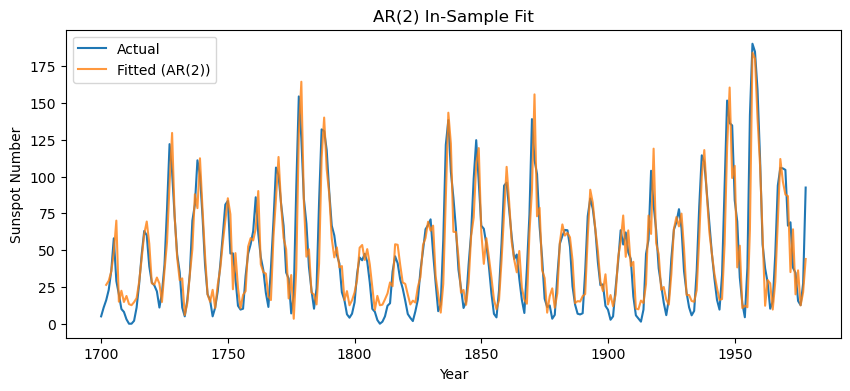

In [10]:
fitted = model.predict(train.values)
fitted_years = train.index[p:]

plt.figure(figsize=(10, 4))
plt.plot(train.index, train.values, label="Actual")
plt.plot(fitted_years, fitted, label="Fitted (AR(2))", alpha=0.8)
plt.xlabel("Year")
plt.ylabel("Sunspot Number")
plt.title("AR(2) In-Sample Fit")
plt.legend()

The fitted line tracks the actual series closely - unsurprising, since one-step-ahead prediction with a strongly autocorrelated series is a comparatively easy problem (today's best guess for tomorrow is "close to today"). The real test is forecasting *forward*, using our own predictions as inputs, which is a much harder problem. Let's forecast the 30 held-out years and see how it does.

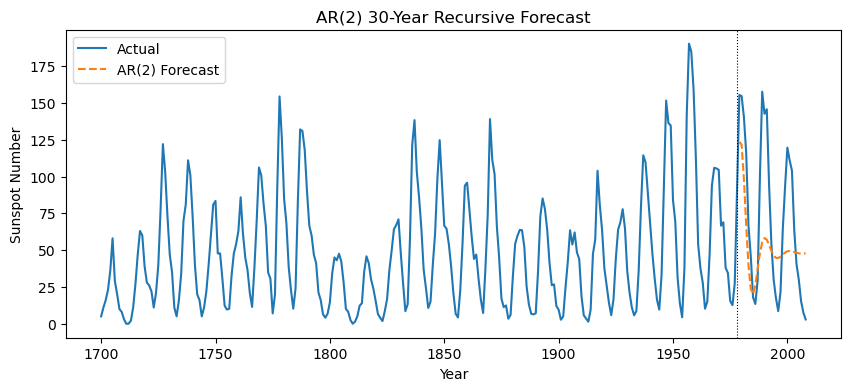

In [11]:
forecast = model.forecast(train.values, steps=len(test))

plt.figure(figsize=(10, 4))
plt.plot(series.index, series.values, label="Actual")
plt.plot(test.index, forecast, label="AR(2) Forecast", linestyle="--")
plt.axvline(train.index[-1], color="black", linewidth=0.8, linestyle=":")
plt.xlabel("Year")
plt.ylabel("Sunspot Number")
plt.title("AR(2) 30-Year Recursive Forecast")
plt.legend()

A couple things worth pointing out here.

The forecast does keep oscillating for a while rather than immediately flatlining - that's because our fitted AR(2) has a pair of complex conjugate characteristic roots, which is what produces the wave-like (rather than purely exponential) decay we derived in the math section above. We can back out the implied cycle length directly from those roots, and compare it to the unconditional mean of the series.

In [12]:
c, phi_1, phi_2 = model.betas
roots = np.roots([1, -phi_1, -phi_2])
modulus = np.abs(roots[0])
angle = np.angle(roots[0])
implied_cycle_years = 2 * np.pi / angle
unconditional_mean = c / (1 - phi_1 - phi_2)

print(f"characteristic roots: {roots}")
print(f"modulus (< 1 => stable/mean-reverting): {modulus:.3f}")
print(f"implied cycle length: {implied_cycle_years:.2f} years")
print(f"unconditional mean: {unconditional_mean:.2f}")
print(f"series mean: {series.mean():.2f}")

characteristic roots: [0.68971841+0.45617576j 0.68971841-0.45617576j]
modulus (< 1 => stable/mean-reverting): 0.827
implied cycle length: 10.75 years
unconditional mean: 48.12
series mean: 49.75


A modulus of ~0.83 (safely under 1) confirms the model is stable and mean-reverting rather than exploding. More strikingly, the implied cycle length works out to roughly **10.75 years** - remarkably close to the well documented ~11-year solar cycle - and the unconditional mean (~48) lands right next to the series' actual historical mean. All of that falls straight out of three OLS coefficients fit on 279 numbers, which is a pretty good showing for such a simple model.

The forecast RMSE over the full 30-year test window does come out considerably worse than the in-sample RMSE though.

In [13]:
forecast_rmse = np.sqrt(np.mean((forecast - test.values) ** 2))
print(f"in-sample RMSE:      {model.metrics['RMSE']:.2f}")
print(f"30-year forecast RMSE: {forecast_rmse:.2f}")

in-sample RMSE:      16.28
30-year forecast RMSE: 44.68


That gap is expected, and is one of the most important practical lessons with AR models (and time series forecasting generally): errors compound as they're recursively fed back into the model, and a solar cycle is only *quasi*-periodic - its length and amplitude vary cycle to cycle. An AR(2) fit purely on the last two observed values has no way to know that, so its usefulness drops off well before the 30-year mark. In practice you would lean on AR models most for short-horizon forecasts, and pair them with wider prediction intervals (or a more sophisticated model) the further out you forecast.

## Conclusion
We covered what Auto Regression is intuitively, mathematically, and in code, and saw that under the hood it's really just linear regression on lagged copies of a series. We fit our from-scratch implementation to the same sunspot dataset that inspired the model in 1927, verified it against `statsmodels`, and used it to forecast forward - along the way rediscovering the ~11-year solar cycle from nothing but three OLS coefficients.

I hope this post proves as useful to you reading it as it was to me writing it.

Thanks all for reading.